In [1]:
import sys
import torch
print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

Python: 3.10.19 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 16:41:31) [MSC v.1929 64 bit (AMD64)]
PyTorch: 2.9.1+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 5070 Laptop GPU


In [2]:
# Install required deps for YOLOv8 + HF Hub (safe to re-run)
%pip install -U ultralytics huggingface_hub pillow


Note: you may need to restart the kernel to use updated packages.


# Choose a model
We searched the web and found a data model that was already very good at detecting the chess.com pieces: https://huggingface.co/NAKSTStudio/yolov8m-chess-piece-detection. This model also detects the chessboard, so that eliminates the need to cut out the chessboard ourselves. 

In [2]:
# Load YOLOv8 chess piece detector from Hugging Face
from ultralytics import YOLO
try:
    # Ultralytics can load directly from the Hub using the repo id
    model = YOLO("NAKSTStudio/yolov8m-chess-piece-detection")
except Exception as e:
    # Fallback: download the weights explicitly, then load
    from huggingface_hub import hf_hub_download
    weights_path = hf_hub_download(repo_id="NAKSTStudio/yolov8m-chess-piece-detection", filename="best.pt")
    model = YOLO(weights_path)
print("Loaded model:", model)

c:\Users\tomde\miniconda3\envs\yolov8\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded model: YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(48, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(48, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(96, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(96, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(96, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(192, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(96, eps=0.001, momentum=0.03, affine=True, 

## Model and Dataset Analysis

Since we're using an existing pre-trained model, we don't know the dataset. The model is based on YOLOv8, so that should be fast enough for our application. Both the white pieces, black pieces and the board are detected.


## Visual validation of the selected model
Let's take a look at some images from our test set and visualize the object detection.
On the default images of chess.com, the results are very reliable. The Lichess images also do pretty good. Chess.com also has runescape themed chesspieces: those have more mistakes in them, especially for the bishops, queen and king. The duolingo chess images are the worst, even the colors of the pieces sometimes have mistakes in them, due to the very different color scheme and shape of the chess pieces.

### Chess.com

In [3]:
img_path = "project/chessboards/chrome_164320_as_cropped.png"

# Run inference
results = model.predict(img_path)  # or model.predict(img_path)
# Show results
results[0].show()


image 1/1 c:\Users\tomde\OneDrive\Documentatie - professioneel - opleiding\AI pro 2025-26\Project\project_chess\project\chessboards\chrome_164320_as_cropped.png: 832x832 1 board, 1 white_king, 2 white_rooks, 1 white_bishop, 8 white_pawns, 1 black_king, 1 black_queen, 2 black_rooks, 2 black_bishops, 2 black_knights, 6 black_pawns, 16.1ms
Speed: 4.7ms preprocess, 16.1ms inference, 13.9ms postprocess per image at shape (1, 3, 832, 832)


### chess.com runescape theme

In [4]:
img_path = "project/chessboards/chrome_164950_as_cropped.png"

# Run inference
results = model.predict(img_path)  # or model.predict(img_path)
# Show results
results[0].show()


image 1/1 c:\Users\tomde\OneDrive\Documentatie - professioneel - opleiding\AI pro 2025-26\Project\project_chess\project\chessboards\chrome_164950_as_cropped.png: 832x832 1 board, 4 white_queens, 2 white_rooks, 2 white_knights, 7 white_pawns, 1 black_king, 2 black_queens, 2 black_rooks, 1 black_knight, 6 black_pawns, 118.3ms
Speed: 4.7ms preprocess, 118.3ms inference, 15.6ms postprocess per image at shape (1, 3, 832, 832)


### lichess

In [5]:
img_path = "data/browserscreenshots/chrome_PLBWkMRPmF.png"

# Run inference
results = model.predict(img_path)  # or model.predict(img_path)
# Show results
results[0].show()


image 1/1 c:\Users\tomde\OneDrive\Documentatie - professioneel - opleiding\AI pro 2025-26\Project\project_chess\data\browserscreenshots\chrome_PLBWkMRPmF.png: 832x832 1 board, 1 white_king, 1 white_queen, 2 white_rooks, 2 white_bishops, 2 white_knights, 8 white_pawns, 1 black_king, 1 black_queen, 2 black_rooks, 2 black_bishops, 2 black_knights, 8 black_pawns, 79.8ms
Speed: 3.8ms preprocess, 79.8ms inference, 18.8ms postprocess per image at shape (1, 3, 832, 832)


### duolingo

In [6]:
img_path = "data/browserscreenshots/Screenshot_20251115_130716_Duolingo.jpg"

# Run inference
results = model.predict(img_path)  # or model.predict(img_path)
# Show results
results[0].show()


image 1/1 c:\Users\tomde\OneDrive\Documentatie - professioneel - opleiding\AI pro 2025-26\Project\project_chess\data\browserscreenshots\Screenshot_20251115_130716_Duolingo.jpg: 832x384 1 board, 5 white_pawns, 4 black_pawns, 88.5ms
Speed: 6.4ms preprocess, 88.5ms inference, 5.8ms postprocess per image at shape (1, 3, 832, 384)


# Model Evaluation

To properly evaluate the model, we'll have to create a test dataset. This set is created from our own screenshots. Having this test dataset available will allow us to compare the metrics of our model before and after finetuning.

## Test dataset creation
To create our test dataset, we will use the existing model to annotate our unnannotated screenshots, then export them for correction in CVAT.

**Workflow:**
1. Take screenshots on different chess websites / apps
1. Run inference on unannotated images using the NAKTSTUDIO model
2. Export predictions in COCO format (CVAT-compatible)
3. Import into CVAT for review and correction
4. Export corrected annotations from CVAT
5. Use corrected annotations for further training

In [ ]:
# Auto-annotate unannotated images and export in COCO format for CVAT
import json
from pathlib import Path
from PIL import Image
from datetime import datetime
from tqdm import tqdm

def yolo_to_coco_bbox(x_center, y_center, width, height, img_width, img_height):
    """Convert YOLO format to COCO format (x, y, width, height where x,y is top-left)."""
    abs_x_center = x_center * img_width
    abs_y_center = y_center * img_height
    abs_width = width * img_width
    abs_height = height * img_height
    
    x = max(0, abs_x_center - abs_width / 2)
    y = max(0, abs_y_center - abs_height / 2)
    abs_width = min(abs_width, img_width - x)
    abs_height = min(abs_height, img_height - y)
    
    return [float(round(x, 2)), float(round(y, 2)), float(round(abs_width, 2)), float(round(abs_height, 2))]

def create_coco_categories(model):
    """Create COCO categories from model class names."""
    categories = [{"id": 0, "name": "Chess-pieces", "supercategory": "none"}]
    class_names = model.names
    
    for class_id, class_name in sorted(class_names.items()):
        categories.append({
            "id": class_id + 1,
            "name": class_name,
            "supercategory": "Chess-pieces" if class_name != "board" else "none"
        })
    
    return categories

def auto_annotate_for_cvat(model, input_dir, output_dir, conf_threshold=0.25):
    """
    Auto-annotate images and export in COCO format for CVAT import.
    
    Args:
        model: YOLOv8 model
        input_dir: Directory with unannotated images
        output_dir: Output directory for annotations
        conf_threshold: Confidence threshold for detections
    """
    input_dir = Path(input_dir)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    
    # Find image files
    image_extensions = {'.jpg', '.jpeg', '.png', '.bmp'}
    image_files = [f for f in input_dir.iterdir() if f.suffix.lower() in image_extensions]
    
    if len(image_files) == 0:
        print(f"No images found in {input_dir}")
        return
    
    print(f"Found {len(image_files)} images to annotate")
    
    # Create COCO structure
    coco_data = {
        "info": {
            "year": datetime.now().year,
            "version": "1.0",
            "description": "Auto-annotated using YOLOv8",
            "contributor": "Auto-annotation",
            "date_created": datetime.now().isoformat()
        },
        "licenses": [{"id": 1, "url": "https://creativecommons.org/licenses/by/4.0/", "name": "CC BY 4.0"}],
        "categories": create_coco_categories(model),
        "images": [],
        "annotations": []
    }
    
    # Process images
    annotation_id = 1
    import shutil
    
    print("\nProcessing images...")
    for image_path in tqdm(image_files):
        image_id = len(coco_data["images"]) + 1
        
        # Get image info
        img = Image.open(image_path)
        width, height = img.size
        coco_data["images"].append({
            "id": image_id,
            "file_name": image_path.name,
            "width": width,
            "height": height,
            "license": 1,
            "date_captured": datetime.now().isoformat()
        })
        
        # Run inference
        results = model.predict(str(image_path), conf=conf_threshold, verbose=False)
        
        if results and len(results) > 0:
            boxes = results[0].boxes
            if boxes is not None and len(boxes) > 0:
                for i in range(len(boxes)):
                    cls_id = int(boxes.cls[i].cpu().numpy())
                    box_xywhn = boxes.xywhn[i].cpu().numpy()
                    x_center, y_center, width_norm, height_norm = box_xywhn
                    
                    bbox_coco = yolo_to_coco_bbox(x_center, y_center, width_norm, height_norm, width, height)
                    area = bbox_coco[2] * bbox_coco[3]
                    
                    coco_data["annotations"].append({
                        "id": annotation_id,
                        "image_id": image_id,
                        "category_id": cls_id + 1,
                        "segmentation": [],
                        "area": round(area, 2),
                        "bbox": bbox_coco,
                        "iscrowd": 0
                    })
                    annotation_id += 1
        
        # Copy image to output
        shutil.copy2(image_path, output_dir / image_path.name)
    
    # Save COCO JSON
    output_json = output_dir / "auto_annotations.coco.json"
    with open(output_json, 'w') as f:
        json.dump(coco_data, f, indent=2)
    
    print(f"\n✓ Annotation complete!")
    print(f"  Images: {len(coco_data['images'])}")
    print(f"  Annotations: {len(coco_data['annotations'])}")
    print(f"  Output: {output_dir}")
    print(f"  COCO JSON: {output_json}")
    print(f"\n📋 Next steps:")
    print(f"  0. Make task in CVAT upload pictures and make the labels in CVAT which are in COCO dataset")
    print(f"  1. Import '{output_json.name}' into CVAT")
    print(f"  2. Review and correct annotations in CVAT")
    print(f"  3. Export corrected annotations from CVAT")
    print(f"  4. Use for training!")

auto_annotate_for_cvat(
    model=model,
    input_dir="data/browserscreenshots",
    output_dir="data/auto_annotated_browserscreenshots",
    conf_threshold=0.25
)

Found 19 images to annotate

Processing images...


100%|██████████| 19/19 [00:00<00:00, 21.16it/s]


✓ Annotation complete!
  Images: 19
  Annotations: 384
  Output: data\auto_annotated_browserscreenshots
  COCO JSON: data\auto_annotated_browserscreenshots\auto_annotations.coco.json

📋 Next steps:
  1. Import 'auto_annotations.coco.json' into CVAT
  2. Review and correct annotations in CVAT
  3. Export corrected annotations from CVAT
  4. Use for training!


## Dataset evaluation with the base model

In [8]:
## Dataset evaluation
metrics = model.val(data="data/auto_annotated_browserscreenshots_yolo/dataset.yaml")

Ultralytics 8.3.233  Python-3.10.19 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 5070 Laptop GPU, 8151MiB)
val: Fast image access  (ping: 0.60.1 ms, read: 328.7158.2 MB/s, size: 330.8 KB)
val: Scanning C:\Users\tomde\OneDrive\Documentatie - professioneel - opleiding\AI pro 2025-26\Project\project_chess\data\auto_annotated_browserscreenshots_yolo\train.cache... 59 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 59/59  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.1s/it 4.3s1.0ss
                   all         59       1416      0.938      0.852      0.952      0.949
                 board         59         59      0.818          1      0.995      0.995
            white_king         59         62       0.95      0.694       0.88      0.869
           white_queen         35         42      0.838       0.86      0.951      0.951
            white_rook         52         84          1      0.883      0.968      0

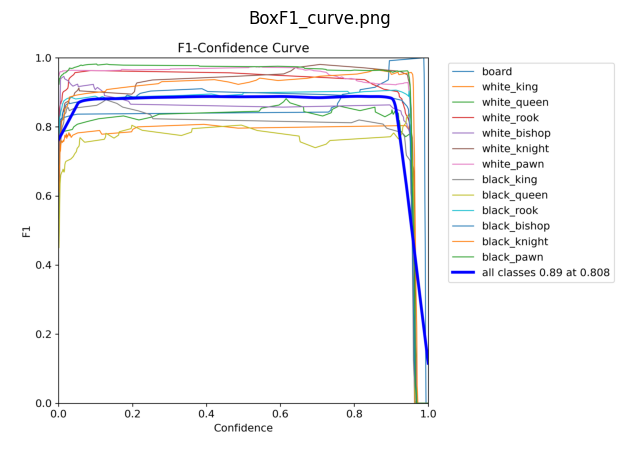

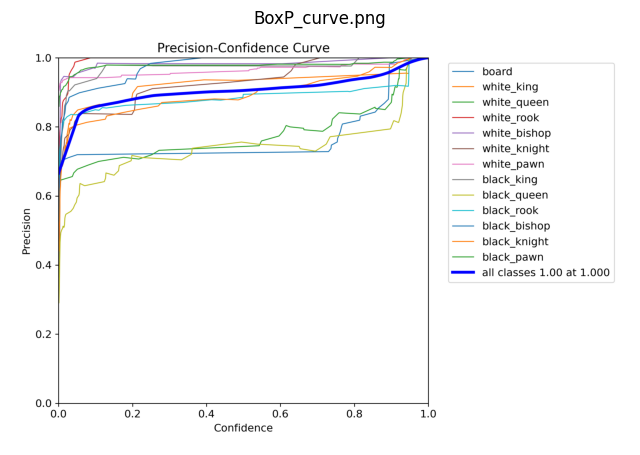

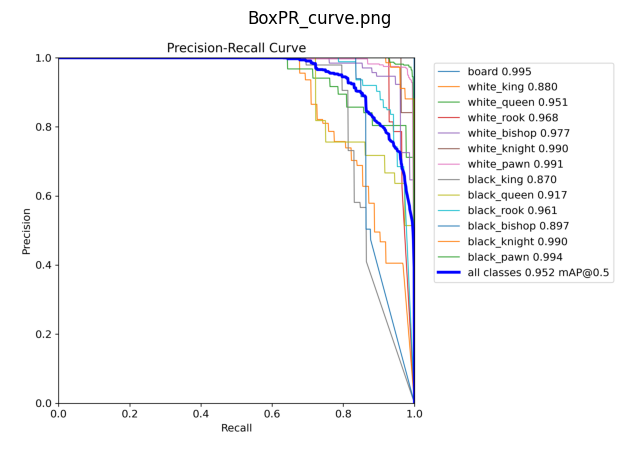

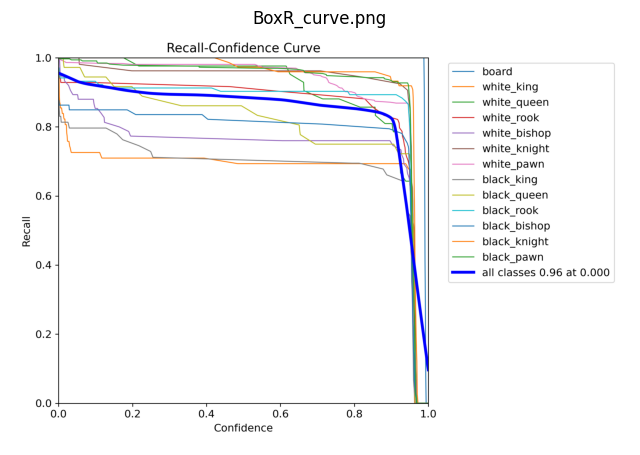

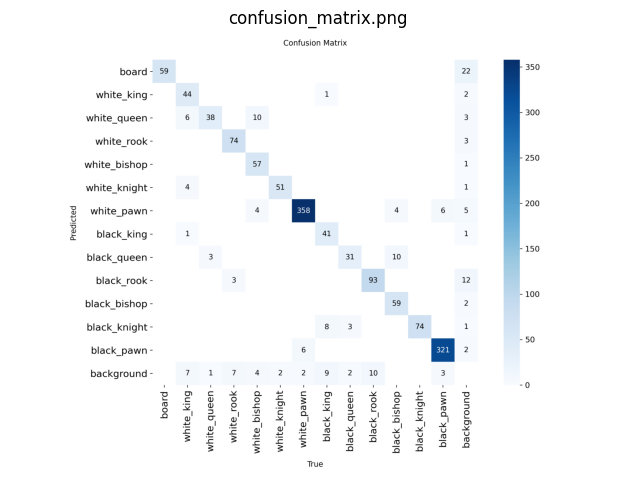

In [10]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# Folder where your images are stored
val_dir = "C:/Users/tomde/OneDrive/Documentatie - professioneel - opleiding/AI pro 2025-26/Project/project_chess/runs/detect/val12"

# Explicit list of the metric plot files you want to display
target_files = [
    "BoxF1_curve.png",
    "BoxP_curve.png",
    "BoxPR_curve.png",
    "BoxR_curve.png",
    "confusion_matrix.png",
    #"confusion_matrix_normalized.png"
]

# Loop through each file and display it
for filename in target_files:
    path = os.path.join(val_dir, filename)
    if os.path.exists(path):
        img = mpimg.imread(path)
        plt.figure(figsize=(8, 6))
        plt.imshow(img)
        plt.axis("off")
        plt.title(filename)
        plt.show()
    else:
        print(f"File not found: {path}")


### Conclusions
The model is performing fairly well. As we could see from the visual comparison, bishop, queens and knight are the least reliable detections. This is especially caused by the Runescape themed chess.com pieces and the Duolingo chess pieces. We also see that the chess pieces with the most confusion are the ones that occur the least on the board.

TODO: zeg iets meer over die plots

# Fine-Tuning the Model with Additional Images

## Creation of training data
To create additional training data, we annotated the starting positions for 4 applications: chess.com, chess.com runescape theme, lichess.org and duolingo. From those 4 images, we created some synthetic data by shuffling the content around, while making sure it was still in a checkerboard pattern. This ensures that all pieces can occur in all places on the chess board, and that every training chess board contains all pieces. This increases the amount of not-pawn pieces in our dataset.

### Example annotated base images
These 4 images were annotated manually

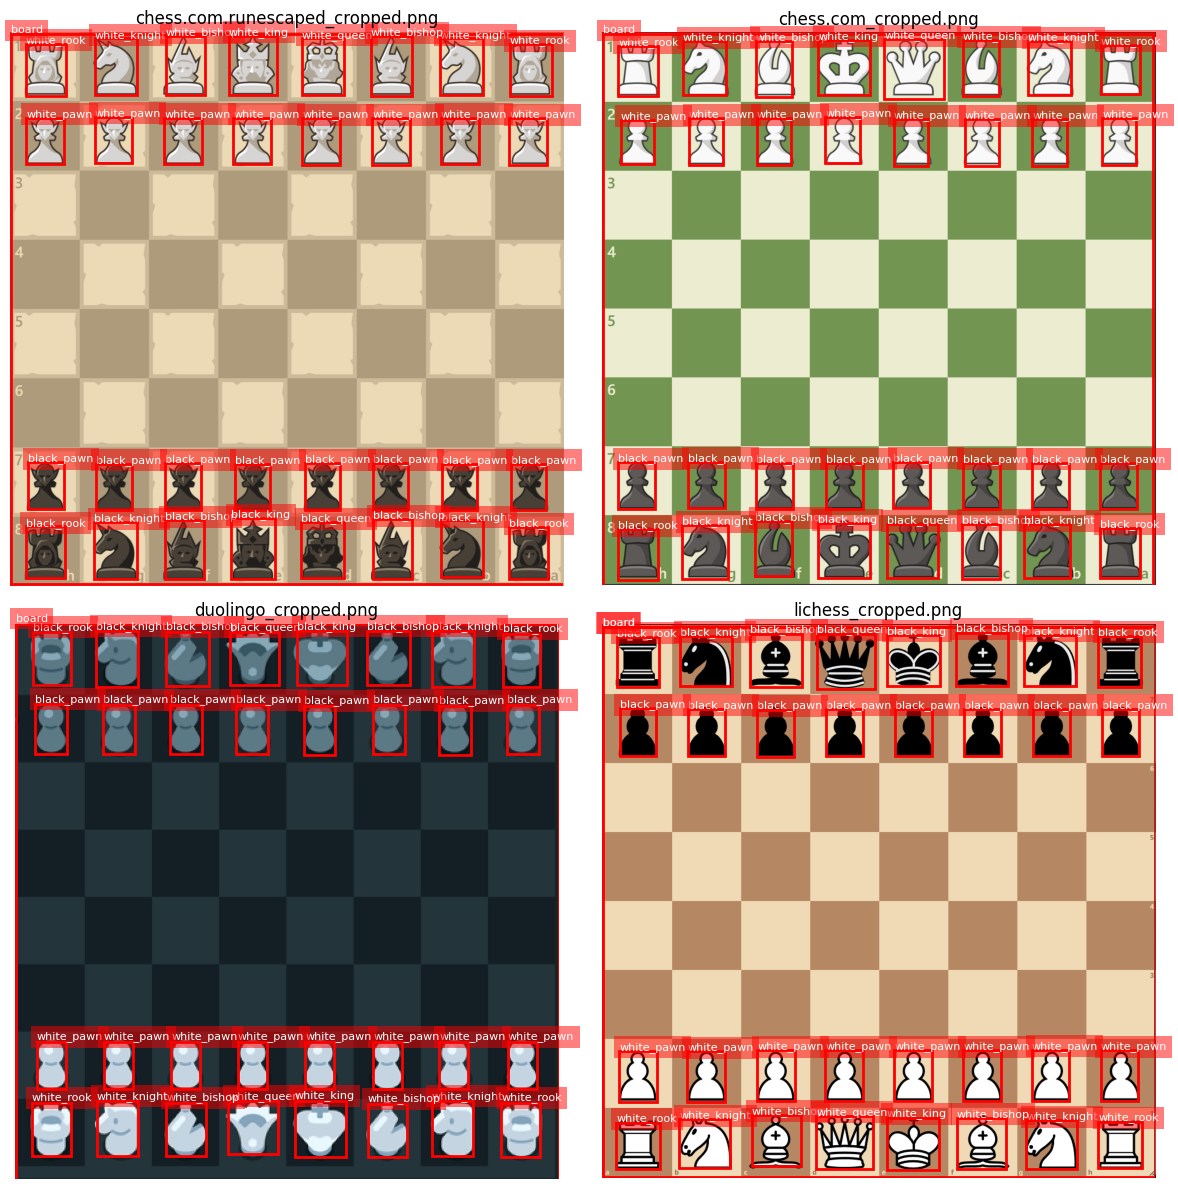

In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
import json
import os
from collections import defaultdict

# Paths
coco_json = "data/synthetic_data/instances_default_corrected.json"
images_dir = "data/synthetic_data/"

# Load COCO data
with open(coco_json, "r") as f:
    coco = json.load(f)

images = coco["images"]
annotations = coco["annotations"]
categories = coco.get("categories", [])

# Build image_id -> annotations mapping
anns_per_image = defaultdict(list)
for ann in annotations:
    anns_per_image[ann["image_id"]].append(ann)

# Build category_id -> name mapping (optional, for labels)
cat_id_to_name = {c["id"]: c["name"] for c in categories}

def draw_coco_image_with_anns(ax, img_path, anns, cat_id_to_name):
    """Draw a single image + its COCO annotations on the given Axes."""
    # Read image (BGR with cv2) and convert to RGB for matplotlib
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        ax.set_title(f"Could not load {os.path.basename(img_path)}")
        ax.axis("off")
        return

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)
    ax.axis("off")
    ax.set_title(os.path.basename(img_path))

    # Add bounding boxes
    for ann in anns:
        # COCO bbox: [x, y, width, height]
        x, y, w, h = ann["bbox"]

        # Rectangle patch
        rect = patches.Rectangle(
            (x, y),
            w,
            h,
            linewidth=2,
            edgecolor="red",
            facecolor="none",
        )
        ax.add_patch(rect)

        # Optional: category label
        cat_id = ann.get("category_id")
        label = cat_id_to_name.get(cat_id, str(cat_id))
        ax.text(
            x,
            y - 2,
            label,
            fontsize=8,
            color="white",
            bbox=dict(facecolor="red", alpha=0.5, linewidth=0),
        )

# Show first 4 images in 2x2 grid
fig, axs = plt.subplots(2, 2, figsize=(12, 12))
axs = axs.flatten()

for idx, img_info in enumerate(images[:4]):
    img_path = os.path.join(images_dir, img_info["file_name"])
    anns = anns_per_image[img_info["id"]]
    draw_coco_image_with_anns(axs[idx], img_path, anns, cat_id_to_name)

# Hide any unused axes (if <4 images)
for j in range(len(images[:4]), len(axs)):
    axs[j].axis("off")

plt.tight_layout()
plt.show()


### Example first attempt at annotated synthetic images
As a first attempt, we tried copying the top row to all odd rows, and the bottom rows to all even rows. This creates a very predictable dataset, where the knight is always in the second and the seventh column. We also create only 4 images this way. (See script scripts/create_synthetic_chessboards.py)

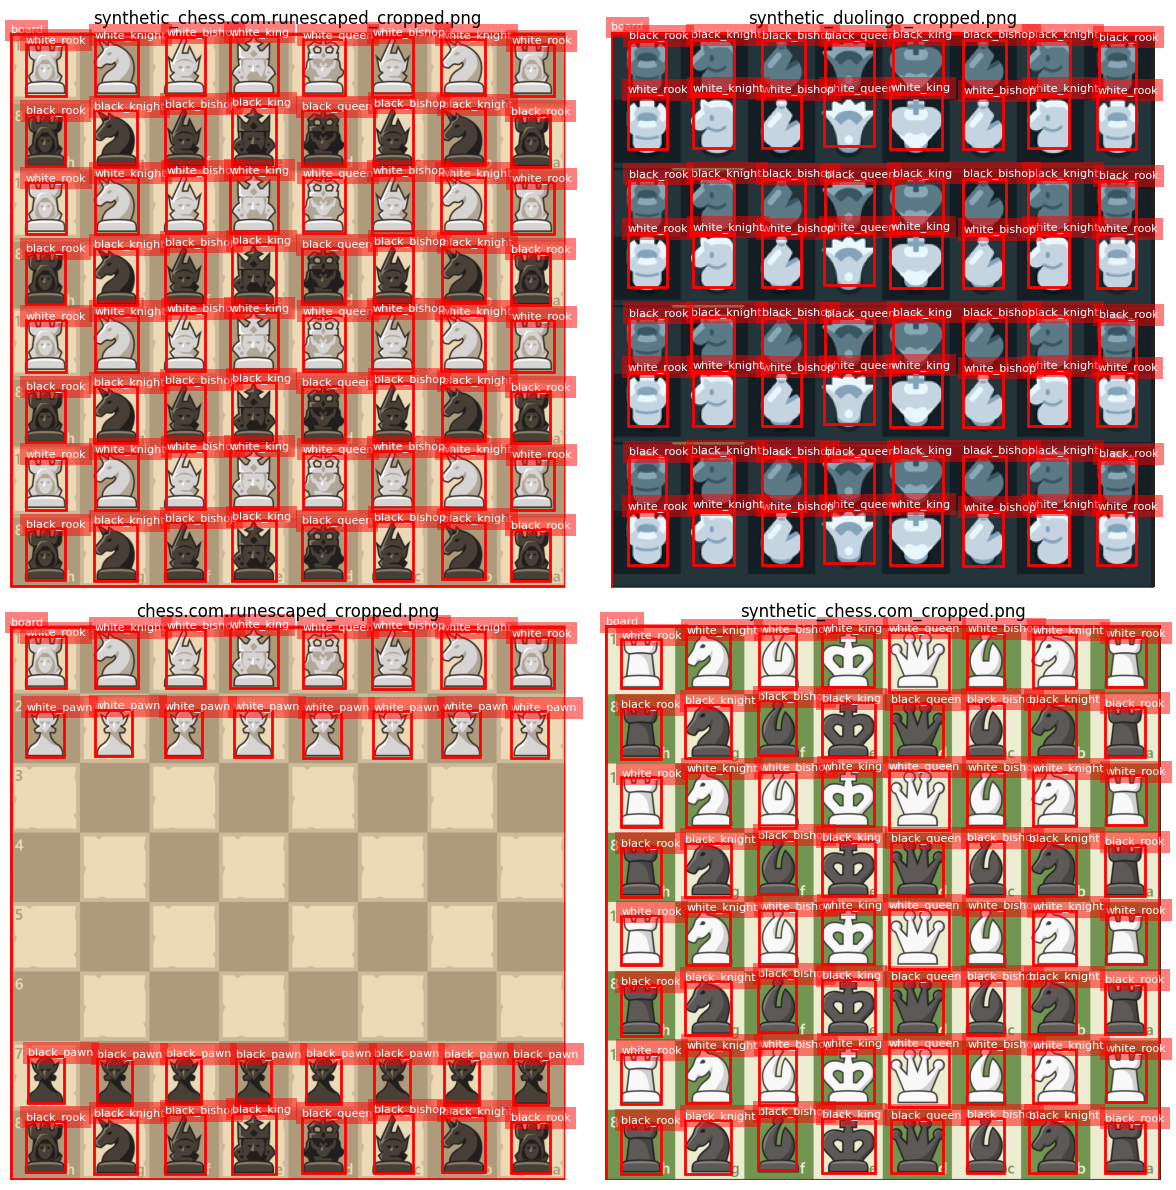

In [16]:
import random
# Paths for the merged dataset
coco_json_merged = "data/synthetic_data/synthetic_output/instances_synthetic.json"
images_dir_merged = "data/synthetic_data/synthetic_output"  # adjust if images live elsewhere

# Load COCO data (merged)
with open(coco_json_merged, "r") as f:
    coco_merged = json.load(f)

images_merged = coco_merged["images"]
annotations_merged = coco_merged["annotations"]
categories_merged = coco_merged.get("categories", [])

# Build image_id -> annotations mapping
anns_per_image_merged = defaultdict(list)
for ann in annotations_merged:
    anns_per_image_merged[ann["image_id"]].append(ann)

# category_id -> name mapping
cat_id_to_name_merged = {c["id"]: c["name"] for c in categories_merged}

# Randomly sample 4 images (or fewer if dataset is tiny)
num_to_show = min(4, len(images_merged))
sampled_images = random.sample(images_merged, num_to_show)

# Plot in 2x2 grid
fig, axs = plt.subplots(2, 2, figsize=(12, 12))
axs = axs.flatten()

for idx, img_info in enumerate(sampled_images):
    img_path = os.path.join(images_dir_merged, img_info["file_name"])
    anns = anns_per_image_merged[img_info["id"]]
    draw_coco_image_with_anns(axs[idx], img_path, anns, cat_id_to_name_merged)

# Hide unused axes if fewer than 4 images
for j in range(num_to_show, len(axs)):
    axs[j].axis("off")

plt.tight_layout()
plt.show()


### Example 2nd attempt at annotated synthetic images
To create more synthetic images, the image was divided in 64 squares and then randomly shuffled into a new board. (see script scripts/shuffle_chessboard_squares.py and merge_coco_datasets.py to merge the results with the previous set)

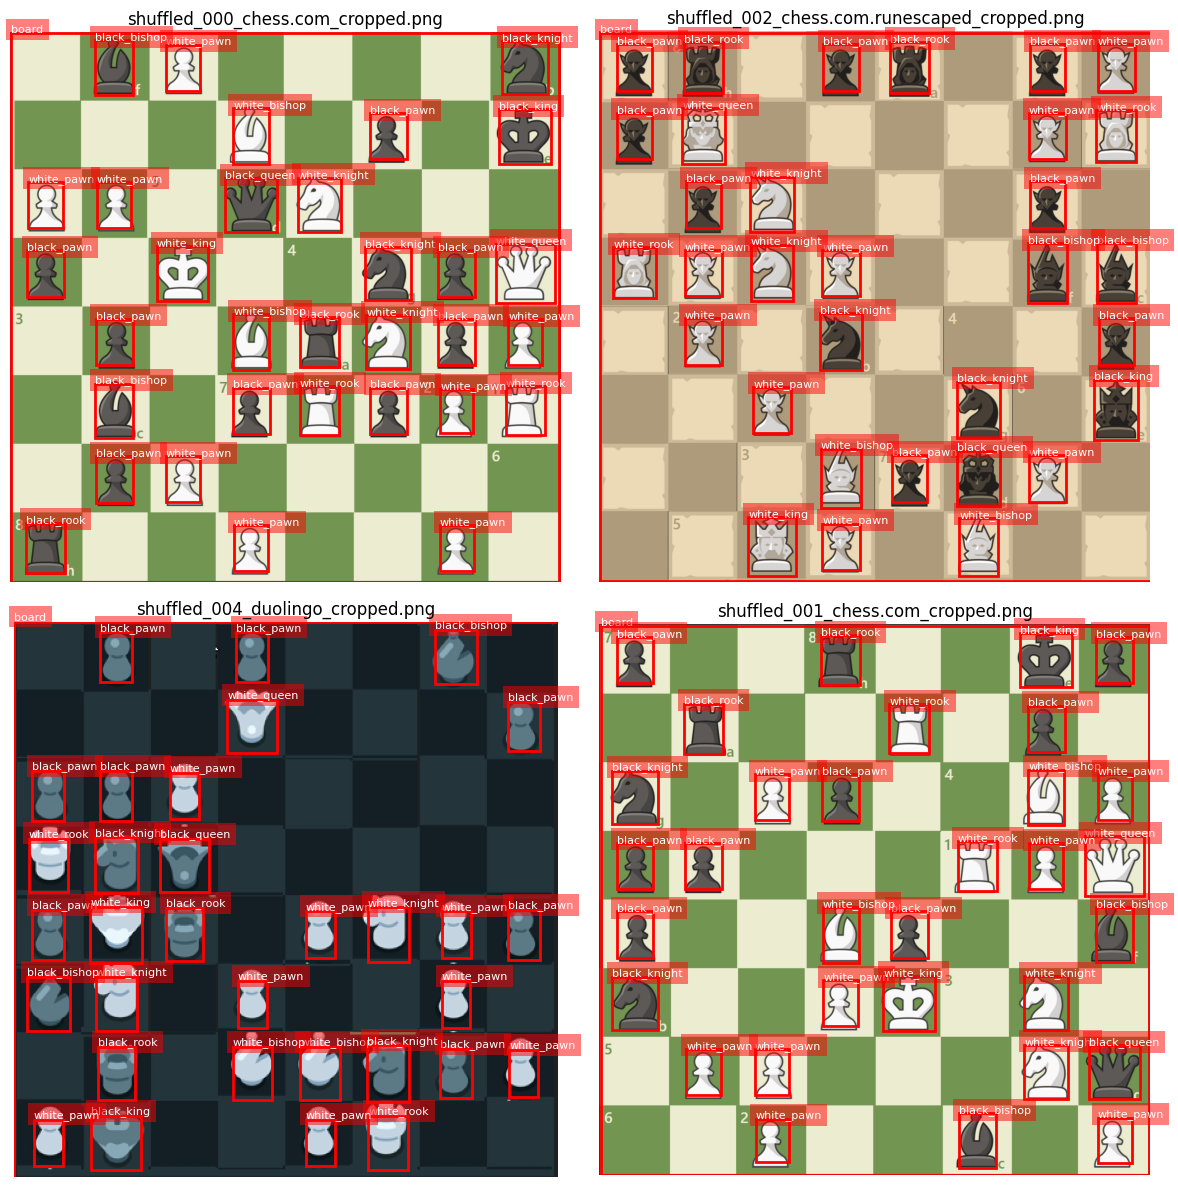

In [38]:
# Paths for the merged dataset
coco_json_merged = "data/synthetic_data/shuffled_output/instances_shuffled.json"
images_dir_merged = "data/synthetic_data/shuffled_output"  # adjust if images live elsewhere

# Load COCO data (merged)
with open(coco_json_merged, "r") as f:
    coco_merged = json.load(f)

images_merged = coco_merged["images"]
annotations_merged = coco_merged["annotations"]
categories_merged = coco_merged.get("categories", [])

# Build image_id -> annotations mapping
anns_per_image_merged = defaultdict(list)
for ann in annotations_merged:
    anns_per_image_merged[ann["image_id"]].append(ann)

# category_id -> name mapping
cat_id_to_name_merged = {c["id"]: c["name"] for c in categories_merged}

# Randomly sample 4 images (or fewer if dataset is tiny)
num_to_show = min(4, len(images_merged))
sampled_images = random.sample(images_merged, num_to_show)

# Plot in 2x2 grid
fig, axs = plt.subplots(2, 2, figsize=(12, 12))
axs = axs.flatten()

for idx, img_info in enumerate(sampled_images):
    img_path = os.path.join(images_dir_merged, img_info["file_name"])
    anns = anns_per_image_merged[img_info["id"]]
    draw_coco_image_with_anns(axs[idx], img_path, anns, cat_id_to_name_merged)

# Hide unused axes if fewer than 4 images
for j in range(num_to_show, len(axs)):
    axs[j].axis("off")

plt.tight_layout()
plt.show()


In [36]:
import json
from collections import Counter

# Load COCO file
with open(coco_json_merged, "r") as f:
    coco = json.load(f)

# Map category_id -> name
cat_id_to_name = {cat["id"]: cat["name"] for cat in coco["categories"]}

# Count category occurrences
category_counts = Counter(
    ann["category_id"] for ann in coco["annotations"]
)

total = sum(category_counts.values())

# Print nicely: count + %
for cat_id, count in category_counts.most_common():
    name = cat_id_to_name[cat_id]
    pct = 100 * count / total
    print(f"{name:15s}: {count:6d}  ({pct:5.2f}%)")


black_pawn     :    192  (24.21%)
white_pawn     :    192  (24.21%)
black_knight   :     48  ( 6.05%)
black_rook     :     48  ( 6.05%)
white_knight   :     48  ( 6.05%)
black_bishop   :     48  ( 6.05%)
white_bishop   :     48  ( 6.05%)
white_rook     :     48  ( 6.05%)
board          :     25  ( 3.15%)
black_queen    :     24  ( 3.03%)
white_queen    :     24  ( 3.03%)
white_king     :     24  ( 3.03%)
black_king     :     24  ( 3.03%)


C:\Users\tomde\AppData\Local\Temp\ipykernel_2172\1357030692.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


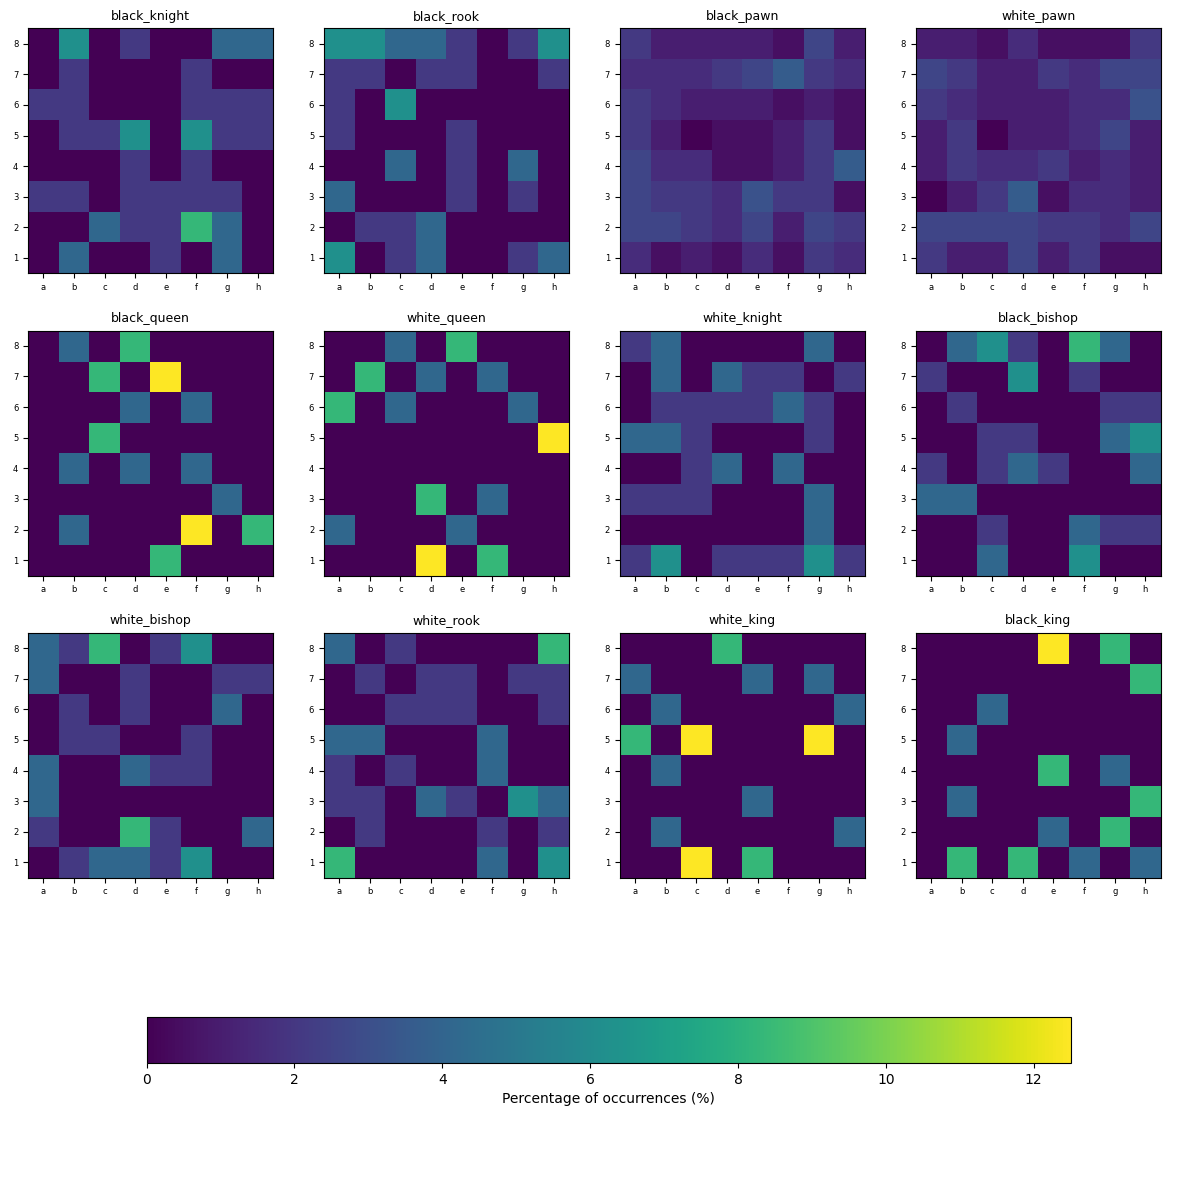

In [35]:
import numpy as np

def bbox_to_square(bbox, img_w, img_h):
    x, y, w, h = bbox
    cx = x + w / 2
    cy = y + h / 2

    col = int(cx / img_w * 8)
    row = int(cy / img_h * 8)

    # Clamp to [0,7]
    col = min(max(col, 0), 7)
    row = min(max(row, 0), 7)

    return row, col

from collections import defaultdict

# Map image_id -> (width, height)
image_sizes = {
    img["id"]: (img["width"], img["height"])
    for img in coco["images"]
}

# One 8x8 grid per category
heatmaps = defaultdict(lambda: np.zeros((8, 8), dtype=int))

for ann in coco["annotations"]:
    img_w, img_h = image_sizes[ann["image_id"]]
    row, col = bbox_to_square(ann["bbox"], img_w, img_h)
    cat_name = cat_id_to_name[ann["category_id"]]
    heatmaps[cat_name][row, col] += 1
heatmaps.pop("board", None)
import matplotlib.pyplot as plt
# Optional: consistent chessboard labeling
files = list("abcdefgh")
ranks = list(range(8, 0, -1))
import numpy as np
import matplotlib.pyplot as plt
import math

files = list("abcdefgh")
ranks = list(range(8, 0, -1))

labels = list(heatmaps.keys())

n_rows, n_cols = 4, 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 3*n_rows))

axes = axes.flatten()

# Optional: consistent color scale across all plots
vmax = max(
    (grid / grid.sum()*100).max()
    for grid in heatmaps.values()
    if grid.sum() > 0
)

for ax, label in zip(axes, labels):
    grid = heatmaps[label]
    if grid.sum() == 0:
        ax.axis("off")
        continue

    norm_grid = grid / grid.sum()*100

    im = ax.imshow(
        norm_grid,
        origin="upper",
        vmin=0,
        vmax=vmax
    )

    ax.set_title(label, fontsize=9)
    ax.set_xticks(range(8))
    ax.set_yticks(range(8))
    ax.set_xticklabels(files, fontsize=6)
    ax.set_yticklabels(ranks, fontsize=6)

# Turn off unused subplots
for ax in axes[len(labels):]:
    ax.axis("off")

# Shared colorbar
cbar = fig.colorbar(
    im,
    ax=axes.ravel().tolist(),
    orientation="horizontal",
    fraction=0.05,
    pad=0.08
)

cbar.set_label("Percentage of occurrences (%)")

plt.tight_layout()
plt.show()


## Finetune the model

### Load the training dataset

In [39]:
import json
from pathlib import Path

# Check dataset paths - using test dataset for fine-tuning
dataset_base = Path("data/synthetic_data/shuffled_output/")
training_json = dataset_base / "instances_shuffled.json"

# Load and analyze test data for fine-tuning
if training_json.exists():
    with open(training_json, 'r') as f:
        training_data = json.load(f)
    
    print(f"\n1. Dataset info:")
    print(f"   Images: {len(training_data['images'])}")
    print(f"   Annotations: {len(training_data['annotations'])}")
    print(f"   Categories: {len(training_data['categories'])}")

else:
    print("⚠ Training dataset not found!")


1. Dataset info:
   Images: 24
   Annotations: 793
   Categories: 13


### Convert the COCO format to YOLO format

In [40]:
# Convert COCO format to YOLO format (required for YOLOv8 training)
# YOLOv8 requires YOLO format: one .txt file per image with normalized coordinates

from pathlib import Path
import json
import shutil
import yaml

print("=" * 70)
print("CONVERTING COCO TO YOLO FORMAT")
print("=" * 70)

def convert_coco_to_yolo(coco_json_path, images_dir, output_dir, class_mapping):
    """
    Convert COCO format annotations to YOLO format.
    
    Args:
        coco_json_path: Path to COCO JSON file
        images_dir: Directory containing images
        output_dir: Output directory for YOLO format
        class_mapping: Dict mapping COCO category names to YOLO class IDs
    """
    # Create output directory
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    
    # Load COCO data
    with open(coco_json_path, 'r') as f:
        coco_data = json.load(f)
    
    # Create image ID to filename mapping
    image_id_to_info = {img['id']: img for img in coco_data['images']}
    
    # Group annotations by image
    annotations_by_image = {}
    for ann in coco_data['annotations']:
        img_id = ann['image_id']
        if img_id not in annotations_by_image:
            annotations_by_image[img_id] = []
        annotations_by_image[img_id].append(ann)
    
    # Process each image
    converted_count = 0
    for img_id, img_info in image_id_to_info.items():
        img_filename = img_info['file_name']
        img_width = img_info['width']
        img_height = img_info['height']
        
        # Find corresponding image file
        img_path = Path(images_dir) / img_filename
        if not img_path.exists():
            continue
        
        # Create YOLO annotation file
        txt_filename = Path(img_filename).stem + '.txt'
        txt_path = output_dir / txt_filename
        
        # Get annotations for this image
        annotations = annotations_by_image.get(img_id, [])
        
        # Write YOLO format annotations
        with open(txt_path, 'w') as f:
            for ann in annotations:
                category_id = ann['category_id']
                # Find category name
                category_name = None
                for cat in coco_data['categories']:
                    if cat['id'] == category_id:
                        category_name = cat['name']
                        break
                
                if category_name is None:
                    continue
                
                # Map to YOLO class ID
                yolo_class_id = class_mapping.get(category_name)
                if yolo_class_id is None:
                    # Skip if category not in mapping
                    continue
                
                # Get bounding box (COCO format: [x, y, width, height])
                bbox = ann['bbox']
                x, y, w, h = bbox
                
                # Convert to YOLO format (normalized center coordinates)
                x_center = (x + w / 2) / img_width
                y_center = (y + h / 2) / img_height
                width_norm = w / img_width
                height_norm = h / img_height
                
                # Write to file: class_id x_center y_center width height
                f.write(f"{yolo_class_id} {x_center:.6f} {y_center:.6f} {width_norm:.6f} {height_norm:.6f}\n")
        
        # Copy image to output directory
        shutil.copy2(img_path, output_dir / img_filename)
        converted_count += 1
    
    return converted_count

# Create class mapping from COCO category names to model class IDs
print("\n1. Creating class mapping...")

# Load training data to get categories
dataset_base = Path("data/synthetic_data/shuffled_output/")
training_json = dataset_base / "instances_shuffled.json"


if not training_json.exists():
    print(f"⚠ Training dataset not found at: {training_json}")
else:
    with open(training_json, 'r') as f:
        training_data = json.load(f)
    
    # Get model class names (ID -> name)
    model_class_id_to_name = model.names
    model_name_to_id = {name: class_id for class_id, name in model_class_id_to_name.items()}
    
    # Create mapping from COCO category names to YOLO class IDs
    class_mapping = {}
    for cat in training_data['categories']:
        coco_name = cat['name']
        # Try to find matching model class
        coco_lower = coco_name.lower()
        
        # Direct match
        if coco_name in model_name_to_id:
            class_mapping[coco_name] = model_name_to_id[coco_name]
        # Try case-insensitive match
        elif coco_lower in {k.lower(): v for k, v in model_name_to_id.items()}:
            for model_name, model_id in model_name_to_id.items():
                if model_name.lower() == coco_lower:
                    class_mapping[coco_name] = model_id
                    break
        # Special case: "Chess-pieces" might be a generic category
        elif coco_name == "Chess-pieces":
            # Skip this generic category
            continue
        else:
            print(f"   Warning: Could not map '{coco_name}' to model class")
    
    print(f"   Mapped {len(class_mapping)} categories:")
    for coco_name, yolo_id in sorted(class_mapping.items()):
        model_class_name = model_class_id_to_name[yolo_id]
        print(f"      {coco_name} -> {yolo_id} ({model_class_name})")
    
    # Convert dataset - using the manually corrected annotations
    print("\n2. Converting dataset...")
    yolo_base = Path("data/synthetic_data/yolo")
    yolo_base.mkdir(exist_ok=True)
    
    # Since we have a single file, we'll convert it and split it into train/val
    # Or just convert it as-is for training
    coco_json = training_json
    images_dir = dataset_base  # Images are in the same directory as the JSON
    output_dir = yolo_base / "train"  # Put in train directory (you can split later if needed)
    
    if coco_json.exists():
        print(f"\n   Converting dataset from: {coco_json.name}")
        count = convert_coco_to_yolo(coco_json, images_dir, output_dir, class_mapping)
        print(f"      Converted {count} images")
        print(f"      Output directory: {output_dir}")
    else:
        print(f"\n   Dataset not found: {coco_json}")
    
    print(f"\n✓ Conversion complete! YOLO format dataset at: {yolo_base}")

# Create dataset configuration file (YOLOv8 requires a YAML config)

print("=" * 70)
print("CREATING DATASET CONFIGURATION")
print("=" * 70)

# Create dataset YAML file
# Since we only have train data, we'll use train for both train and validation
# (YOLOv8 will automatically split it during training if needed)
yolo_base = Path("data/synthetic_data/yolo")
dataset_config = {
    'path': str(yolo_base.absolute()),
    'train': 'train',  # Training data
    'val': 'train',    # Use train for validation too (or create a split later)
    'nc': len(model.names),  # Number of classes
    'names': list(model.names.values())  # Class names in order
}

config_path = yolo_base / "dataset.yaml"
config_path.parent.mkdir(parents=True, exist_ok=True)
with open(config_path, 'w') as f:
    yaml.dump(dataset_config, f, default_flow_style=False, sort_keys=False)

print(f"\n✓ Dataset config created: {config_path}")
print(f"\nConfig contents:")
print(f"   Path: {dataset_config['path']}")
print(f"   Train: {dataset_config['train']}")
print(f"   Val: {dataset_config['val']} (using train split - will auto-split during training)")
print(f"   Classes: {dataset_config['nc']}")
print(f"   Names: {dataset_config['names']}")

CONVERTING COCO TO YOLO FORMAT

1. Creating class mapping...
   Mapped 13 categories:
      black_bishop -> 10 (black_bishop)
      black_king -> 7 (black_king)
      black_knight -> 11 (black_knight)
      black_pawn -> 12 (black_pawn)
      black_queen -> 8 (black_queen)
      black_rook -> 9 (black_rook)
      board -> 0 (board)
      white_bishop -> 4 (white_bishop)
      white_king -> 1 (white_king)
      white_knight -> 5 (white_knight)
      white_pawn -> 6 (white_pawn)
      white_queen -> 2 (white_queen)
      white_rook -> 3 (white_rook)

2. Converting dataset...

   Converting dataset from: instances_shuffled.json
      Converted 24 images
      Output directory: data\synthetic_data\yolo\train

✓ Conversion complete! YOLO format dataset at: data\synthetic_data\yolo
CREATING DATASET CONFIGURATION

✓ Dataset config created: data\synthetic_data\yolo\dataset.yaml

Config contents:
   Path: c:\Users\tomde\OneDrive\Documentatie - professioneel - opleiding\AI pro 2025-26\Project\pr

## Train the model

In [41]:
model.train(
    data="data/synthetic_data/yolo/dataset.yaml",
    epochs=50,
    imgsz=640,
    batch=2, ## lowered to prevent OOM errors
    workers=2, ## lowered to prevent OOM errors
    erasing=0.1 ## 10% of the images will get random cutouts, this to simulate that a chess piece is sometimes partially hidden by a mouse cursor.
)

New https://pypi.org/project/ultralytics/8.3.237 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.233  Python-3.10.19 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 5070 Laptop GPU, 8151MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data/synthetic_data/yolo/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.1, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=C:\Users\tomde\.cache\huggingface\hub\models--NAKSTStudio--yolov8m-ch

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001C2BAC699F0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.0

## Evaluate the model

In [42]:
## Dataset evaluation
metrics = model.val(data="data/auto_annotated_browserscreenshots_yolo/dataset.yaml")

Ultralytics 8.3.233  Python-3.10.19 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 5070 Laptop GPU, 8151MiB)
Model summary (fused): 92 layers, 25,847,287 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 1810.81001.0 MB/s, size: 430.3 KB)
val: Scanning C:\Users\tomde\OneDrive\Documentatie - professioneel - opleiding\AI pro 2025-26\Project\project_chess\data\auto_annotated_browserscreenshots_yolo\train.cache... 59 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 59/59 9.0Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.0s/it 4.1s1.1ss
                   all         59       1416      0.979      0.908      0.949      0.758
                 board         59         59          1      0.987      0.995      0.967
            white_king         59         62      0.992      0.935      0.948      0.743
           white_queen         35         42          1      0.487      0.818    

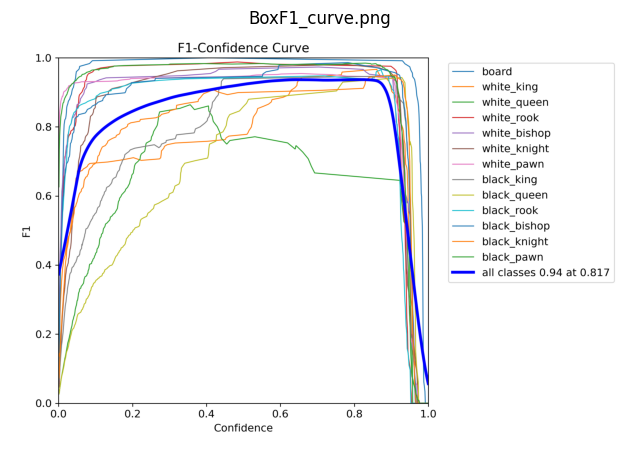

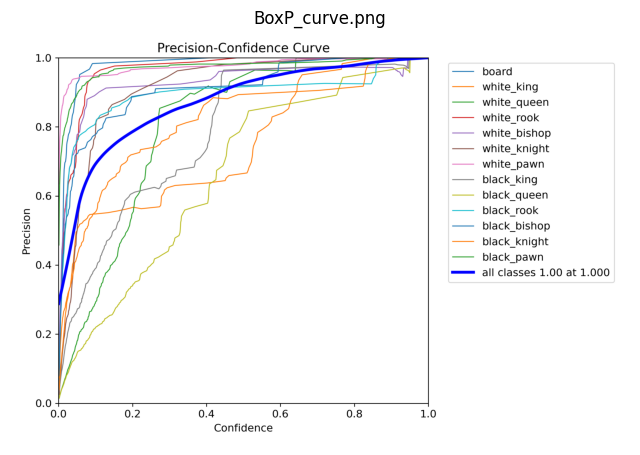

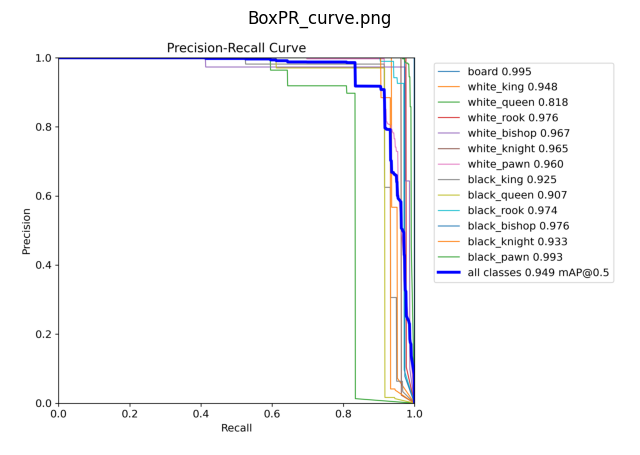

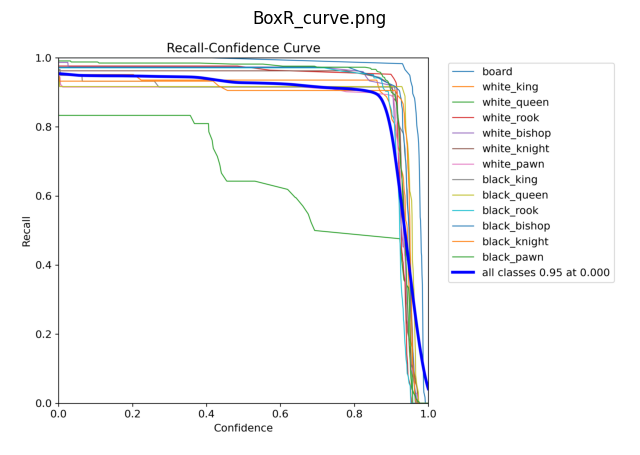

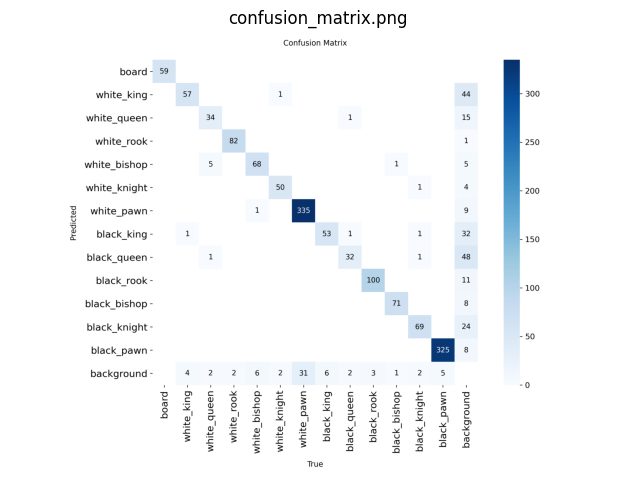

In [44]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# Folder where your images are stored
val_dir = "C:/Users/tomde/OneDrive/Documentatie - professioneel - opleiding/AI pro 2025-26/Project/project_chess/runs/detect/val13"

# Explicit list of the metric plot files you want to display
target_files = [
    "BoxF1_curve.png",
    "BoxP_curve.png",
    "BoxPR_curve.png",
    "BoxR_curve.png",
    "confusion_matrix.png",
    #"confusion_matrix_normalized.png"
]

# Loop through each file and display it
for filename in target_files:
    path = os.path.join(val_dir, filename)
    if os.path.exists(path):
        img = mpimg.imread(path)
        plt.figure(figsize=(8, 6))
        plt.imshow(img)
        plt.axis("off")
        plt.title(filename)
        plt.show()
    else:
        print(f"File not found: {path}")

## Conclusion
Based on the confusion matrix we see a much better results compared to the first initial model without finetuning. Nevertheless there a still a few confusions o black knights which were confused with queen,king & white knight. Also white queen is confused with a withe bischop.

Probably extending the training_set can help to get the result a bit better

## simple yolo model, without departing from pretrained chess model: 

In [ ]:
simple_model = YOLO("yolov8m.pt")  # start with a pre-trained YOLOv8 model
simple_model.train(
    data="data/auto_annotated_browserscreenshots_yolo/dataset.yaml",
    epochs=50,
    imgsz=640,
    batch=2,
    workers=2, 
    erasing=0.1 ## 10% of the images will get random cutouts, this to simulate that a chess piece is sometimes partially hidden by a mouse cursor.
)

In [ ]:
## Dataset evaluation
simple_metrics = simple_model.val(data="data/auto_annotated_browserscreenshots_yolo/dataset.yaml")

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# Folder where your images are stored
val_dir = "/workspace/runs/detect/val5"

# Explicit list of the metric plot files you want to display
target_files = [
    "BoxF1_curve.png",
    "BoxP_curve.png",
    "BoxPR_curve.png",
    "BoxR_curve.png",
    "confusion_matrix.png",
    #"confusion_matrix_normalized.png"
]

# Loop through each file and display it
for filename in target_files:
    path = os.path.join(val_dir, filename)
    if os.path.exists(path):
        img = mpimg.imread(path)
        plt.figure(figsize=(8, 6))
        plt.imshow(img)
        plt.axis("off")
        plt.title(filename)
        plt.show()
    else:
        print(f"File not found: {path}")

# Conversion of object detected model to grid
To prove that our model can convert from an image to a text representation, we converted the object detection output to a text based grid.

In [ ]:
img_path = "data/browserscreenshots/chrome_8BafXl8Lrb.png"

# Run inference
results = model.predict(img_path) 
# Show results
results[0].show()

In [ ]:
import numpy as np

img_path = "data/browserscreenshots/chrome_8BafXl8Lrb.png"
results = model.predict(img_path)
boxes = results[0].boxes
class_names = results[0].names

# Map class names to symbols
piece_symbols = {
    "white_king": "K", "white_queen": "Q", "white_rook": "R", "white_bishop": "B", "white_knight": "N", "white_pawn": "P",
    "black_king": "k", "black_queen": "q", "black_rook": "r", "black_bishop": "b", "black_knight": "n", "black_pawn": "p",
    "board": "."
}

# Find board bounding box
board_box = None
for box in boxes:
    cls_id = int(box.cls)
    if class_names[cls_id] == "board":
        board_box = box.xyxy[0].tolist()
        break

if board_box is None:
    print("No board detected.")
else:
    x1, y1, x2, y2 = board_box
    board_w = x2 - x1
    board_h = y2 - y1

    # Prepare empty board
    board = [["." for _ in range(8)] for _ in range(8)]

    # Place pieces
    for box in boxes:
        cls_id = int(box.cls)
        name = class_names[cls_id]
        if name == "board":
            continue
        # Get center of bounding box
        bx1, by1, bx2, by2 = box.xyxy[0].tolist()
        cx = (bx1 + bx2) / 2
        cy = (by1 + by2) / 2
        # Map to board square
        col = int(8 * (cx - x1) / board_w)
        row = int(8 * (cy - y1) / board_h)
        # Clamp to board
        col = min(max(col, 0), 7)
        row = min(max(row, 0), 7)
        # Place symbol
        board[row][col] = piece_symbols.get(name, "?")

    # Print board (top row first)
    for row in board:
        print(" ".join(row))